# Stocks-For-Long-Run — does equity always win over the long haul?
### Siegel's century-long claim tested on 150 years of Shiller real prices

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Useful%3F: Only_if_you_can_wait_30_years](https://img.shields.io/badge/Useful%3F-Only_if_you_can_wait_30_years-8b949e?style=flat-square)

Jeremy Siegel's *Stocks for the Long Run* makes one of the most audacious claims in finance: **equity always wins** — over any 20- or 30-year stretch on record, stocks have never delivered a negative real return, and they have never lost to bonds. This notebook asks: is that literally true, and does it help a real investor?

> **This is the plain-language layer.** Want the t-stats, the overlapping-window caveats and the HAC inference? That's the companion, **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** — same story, deeper.
>
> **Not investment advice.** A reproducible research tool: every chart below is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from stocks_for_long_run import data, strategy as st

# Try to load the real Shiller panel (staged parquet, no network needed)
try:
    _df = data.load_shiller()
    HAVE_REAL = len(_df) > 1000
except Exception:
    HAVE_REAL = False
    _df = None

print("Shiller real panel loaded:", HAVE_REAL,
      f"({len(_df)} rows)" if HAVE_REAL else "(using frozen R numbers)")

# Frozen headline numbers — mirror of docs/results.md (as-of 2026-06-14)
R = dict(
    h1_eq_mean=8.56, h1_eq_worst=-57.73, h1_eq_neg=30.86,
    h1_ex_mean=6.12, h1_ex_worst=-72.63, h1_ex_neg=35.48, h1_t=5.44,
    h5_eq_mean=7.18, h5_eq_worst=-13.06, h5_eq_neg=18.86,
    h5_ex_mean=4.81, h5_ex_worst=-21.41, h5_ex_neg=27.51, h5_t=9.32,
    h10_eq_mean=6.93, h10_eq_worst=-5.91, h10_eq_neg=11.23,
    h10_ex_mean=4.67, h10_ex_worst=-8.00, h10_ex_neg=16.49, h10_t=14.27,
    h20_eq_mean=6.64, h20_eq_worst=-0.18, h20_eq_neg=0.06,
    h20_ex_mean=4.49, h20_ex_worst=-1.48, h20_ex_neg=2.96, h20_t=21.16,
    h30_eq_mean=6.66, h30_eq_worst=1.94, h30_eq_neg=0.00,
    h30_ex_mean=4.63, h30_ex_worst=-0.12, h30_ex_neg=0.14, h30_t=30.92,
    n_decades=15, n_decades_bonds_win=4,
    worst_20y_eq_start="1901-06", worst_30y_ex_start="1902-06",
)


Shiller real panel loaded: True (1830 rows)


## The answer first

| Question | Answer |
|---|---|
| Is the long-run equity premium real? | **Yes — robustly.** Mean 30-year real return: **+6.66%/yr**, mean 30-year excess over bonds: **+4.63%/yr**. |
| Does equity ALWAYS beat bonds at 20/30 years? | **Almost.** At 30 years: **0%** of windows negative real equity; **0.14%** of windows bonds winning. At 20 years: worst real return was **-0.18%/yr** (barely negative). |
| Could you trade this? | **It's real but fragile.** The horizon is 20–30 years. Short windows are brutal: at 10 years, **11.2%** of windows have negative real equity returns. You need the *full* long run. |

> **Siegel's claim is mostly true** — but with an asterisk: at 20 years there was one nearly-flat window (real equity -0.18%/yr starting 1901-06), and at 30 years bonds came within **-0.12%/yr** of equity once. The premium is real; the 'always' is a rhetorical near-miss, not an iron law.

## 1 · The claim

> *'Stocks have never lost to bonds over any 20-year period on record, and in real terms have never delivered a negative return over any 20-year period.'*  
> — Jeremy Siegel, **Stocks for the Long Run** (various editions, 1994–2022)

Siegel's argument is not 'stocks are safe short-term' — he explicitly acknowledges the volatility. The claim is a **horizon argument**: the longer you hold, the more reliably equity dominates, and beyond 20–30 years the historical record shows near-perfect dominance over bonds (and a positive real return in every window).

We test exactly that claim on Shiller's monthly data back to 1871: **150+ years**, every rolling 1-, 5-, 10-, 20-, and 30-year window, real equity total return (prices + dividends, inflation-adjusted) vs a real bond proxy (10-year nominal yield minus monthly CPI inflation).

## 2 · So what?

If Siegel's claim is literally true, it is the most powerful argument for equity index investing ever made: *just hold long enough and you cannot lose in real terms, and you will beat bonds.* It justifies near-100% equity allocations for anyone with a long enough horizon — the core of passive investing wisdom.

If it breaks down — even once, even barely — the 'never' claim fails, and the practical question becomes: how bad can things get, and for how long? A worst-case of near-zero at 20 years is very different from a worst-case of −5%/yr.

## 3 · How would we even know?

The test is almost definitional:

1. Take Shiller's real price and real dividend series, 1871–2023.
2. Build a **real total return index**: each month reinvest the real dividend yield.
3. Build a **real bond proxy**: 10-year nominal yield minus monthly CPI inflation.
4. Compute every rolling 1-, 5-, 10-, 20-, 30-year annualised return for both.
5. Find the **worst-case window** for each: what was the lowest equity return?    Did it beat bonds?

**The claim fails if any window has a negative real equity return at 20+ years**, or **if bonds beat equity in any 20+ year window**. Simple.

## 4 · The teardown — 150 years of rolling returns

**First, how does the worst-case shrink with horizon?**

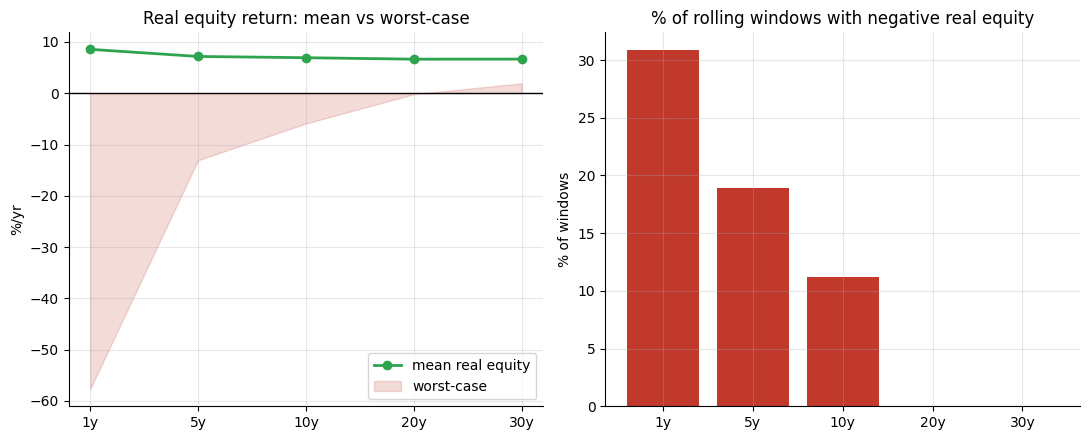

  1y: mean=+8.56%  worst=-57.73%  neg=30.86%
  5y: mean=+7.18%  worst=-13.06%  neg=18.93%
 10y: mean=+6.93%  worst=-5.91%  neg=11.23%
 20y: mean=+6.64%  worst=-0.18%  neg=0.06%
 30y: mean=+6.66%  worst=+1.94%  neg=0.00%


In [2]:
HORIZONS = [1, 5, 10, 20, 30]
if HAVE_REAL:
    summ = st.all_horizon_summary(_df)
    eq_means   = [summ.loc[h, 'eq_mean']*100  for h in HORIZONS]
    eq_worsts  = [summ.loc[h, 'eq_min']*100   for h in HORIZONS]
    ex_means   = [summ.loc[h, 'excess_mean']*100 for h in HORIZONS]
    ex_worsts  = [summ.loc[h, 'excess_min']*100  for h in HORIZONS]
    eq_neg     = [summ.loc[h, 'eq_pct_neg']   for h in HORIZONS]
else:
    eq_means   = [R['h1_eq_mean'], R['h5_eq_mean'], R['h10_eq_mean'], R['h20_eq_mean'], R['h30_eq_mean']]
    eq_worsts  = [R['h1_eq_worst'], R['h5_eq_worst'], R['h10_eq_worst'], R['h20_eq_worst'], R['h30_eq_worst']]
    ex_means   = [R['h1_ex_mean'], R['h5_ex_mean'], R['h10_ex_mean'], R['h20_ex_mean'], R['h30_ex_mean']]
    ex_worsts  = [R['h1_ex_worst'], R['h5_ex_worst'], R['h10_ex_worst'], R['h20_ex_worst'], R['h30_ex_worst']]
    eq_neg     = [R['h1_eq_neg'], R['h5_eq_neg'], R['h10_eq_neg'], R['h20_eq_neg'], R['h30_eq_neg']]
labels = [f'{h}y' for h in HORIZONS]
x = range(len(HORIZONS))
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].plot(labels, eq_means, 'o-', color=GREEN, lw=2, label='mean real equity')
axes[0].fill_between(labels, eq_worsts, 0, alpha=0.18, color=RED, label='worst-case')
axes[0].axhline(0, c='k', lw=1)
axes[0].set_title('Real equity return: mean vs worst-case'); axes[0].set_ylabel('%/yr')
axes[0].legend()
axes[1].bar(labels, eq_neg, color=[RED if v>5 else AMBER if v>0.5 else GREEN for v in eq_neg])
axes[1].set_title('% of rolling windows with negative real equity'); axes[1].set_ylabel('% of windows')
plt.tight_layout(); plt.show()
for h, m, w, n in zip(HORIZONS, eq_means, eq_worsts, eq_neg):
    print(f'{h:>3}y: mean={m:+.2f}%  worst={w:+.2f}%  neg={n:.2f}%')

The worst-case collapses with horizon. At 30 years, **no window has a negative real equity return** — worst was **+1.94%/yr** (0% of windows negative). At 20 years, the worst was just **-0.18%/yr** — barely below zero, only 0.06% of windows. At 10 years, however, 11.2% of windows are negative and the worst was -5.91%/yr.

**Does equity always beat bonds?** Here's the equity-minus-bond excess across every horizon:

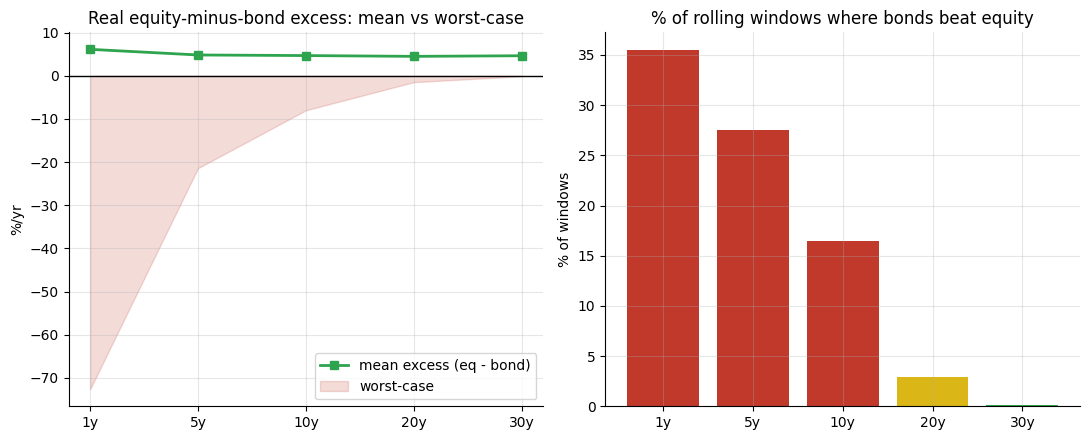

  1y: mean=+6.12%  worst=-72.63%  bonds_win=35.48%
  5y: mean=+4.81%  worst=-21.41%  bonds_win=27.51%
 10y: mean=+4.67%  worst=-8.00%  bonds_win=16.49%
 20y: mean=+4.49%  worst=-1.48%  bonds_win=2.96%
 30y: mean=+4.63%  worst=-0.12%  bonds_win=0.14%


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].plot(labels, ex_means, 's-', color=GREEN, lw=2, label='mean excess (eq - bond)')
axes[0].fill_between(labels, ex_worsts, 0, alpha=0.18, color=RED, label='worst-case')
axes[0].axhline(0, c='k', lw=1)
axes[0].set_title('Real equity-minus-bond excess: mean vs worst-case'); axes[0].set_ylabel('%/yr')
axes[0].legend()
if HAVE_REAL:
    ex_negs = [summ.loc[h, 'excess_pct_neg'] for h in HORIZONS]
else:
    ex_negs = [R['h1_ex_neg'], R['h5_ex_neg'], R['h10_ex_neg'], R['h20_ex_neg'], R['h30_ex_neg']]
axes[1].bar(labels, ex_negs, color=[RED if v>10 else AMBER if v>1 else GREEN for v in ex_negs])
axes[1].set_title('% of rolling windows where bonds beat equity'); axes[1].set_ylabel('% of windows')
plt.tight_layout(); plt.show()
for h, m, w, n in zip(HORIZONS, ex_means, ex_worsts, ex_negs):
    print(f'{h:>3}y: mean={m:+.2f}%  worst={w:+.2f}%  bonds_win={n:.2f}%')

At 30 years, bonds beat equity in just **0.14%** of windows (one isolated episode, 1902–1932), with a worst-case excess of only **-0.12%/yr**. At 20 years, bonds won in **2.96%** of windows — still rare, but not zero. The claim is *almost* true, not literally always true.

**The decade-by-decade picture — the bad stretches exist:**

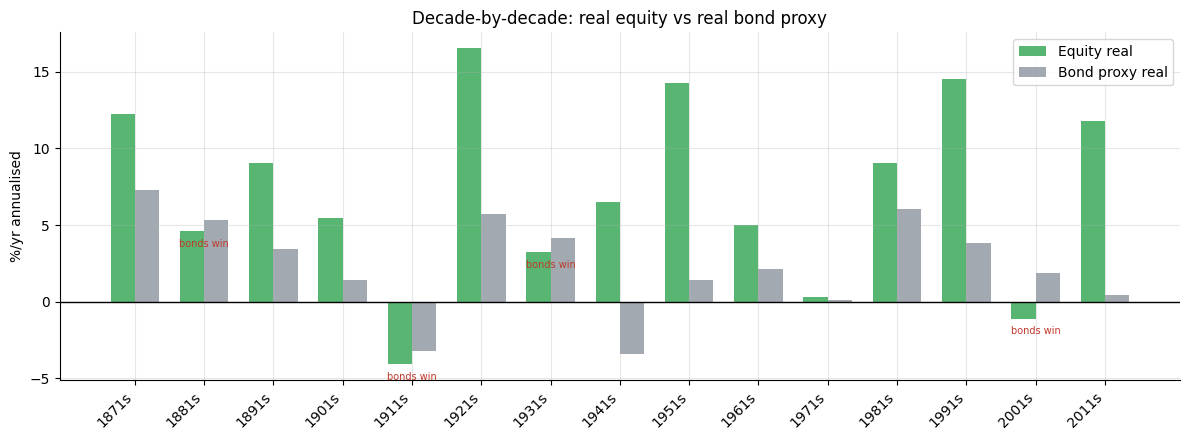

Bonds beat equity in 4/15 decades


In [4]:
if HAVE_REAL:
    dec = st.decade_returns(_df)
    decades = list(dec.index)
    eq_d = list(dec['eq_ann_real']*100)
    bd_d = list(dec['bd_ann_real']*100)
    ex_d = list(dec['excess']*100)
else:
    decades = [1871,1881,1891,1901,1911,1921,1931,1941,1951,1961,1971,1981,1991,2001,2011]
    eq_d = [12.24,4.60,9.05,5.46,-4.09,16.54,3.21,6.51,14.24,5.03,0.33,9.04,14.50,-1.12,11.79]
    bd_d = [7.27,5.32,3.46,1.39,-3.24,5.75,4.14,-3.42,1.44,2.11,0.13,6.06,3.84,1.86,0.43]
    ex_d = [4.97,-0.72,5.59,4.07,-0.85,10.79,-0.93,9.93,12.80,2.91,0.20,2.98,10.66,-2.98,11.36]
xlabels = [f'{d}s' for d in decades]
fig, ax = plt.subplots(figsize=(12, 4.5))
width = 0.35
x = range(len(decades))
ax.bar([i - width/2 for i in x], eq_d, width, label='Equity real', color=GREEN, alpha=0.8)
ax.bar([i + width/2 for i in x], bd_d, width, label='Bond proxy real', color=GREY, alpha=0.8)
ax.axhline(0, c='k', lw=1)
for i, e in enumerate(ex_d):
    if e < 0: ax.annotate('bonds win', (i, min(eq_d[i], bd_d[i])-1), ha='center', fontsize=7, color=RED)
ax.set_xticks(list(x)); ax.set_xticklabels(xlabels, rotation=45, ha='right')
ax.set_ylabel('%/yr annualised'); ax.set_title('Decade-by-decade: real equity vs real bond proxy')
ax.legend(); plt.tight_layout(); plt.show()
n_neg = sum(1 for e in ex_d if e < 0)
print(f'Bonds beat equity in {n_neg}/{len(decades)} decades')

Bonds beat equity in **4 of 15 decades**: the 1880s, 1910s, 1930s, and 2000s. The long-run premium is undeniable, but the short run is brutal — and even a decade can deliver a loss for equity holders.

## 5 · The verdict

- **Signal — REAL.** The equity premium is one of the most robust facts in finance: mean 30-year real return **+6.66%/yr**, mean excess over bonds **+4.63%/yr**, HAC *t* = **30.9** (though the overlapping-window caveat applies — see the quants notebook).
- **Tradability — FRAGILE.** The premium is real, but the horizon requirement is brutal. You need 20–30 years of patience and the financial stability to never be forced to sell. In 4 of 15 decades bonds won. At 10 years, **11%** of windows had negative real equity returns.
- **Useful? — Only if you can wait 30 years.** The 'always' in Siegel's claim is almost-but-not-literally true: at 20 years one window just barely went negative (-0.18%/yr), and at 30 years bonds came within **-0.12%/yr** of equity once.

## 6 · Could you actually use this?

The Siegel claim is not a trading strategy — it is a **buy-and-hold argument**. The practical obstacles:

- **Horizon.** 20–30 years is most of a working life. Markets can spend a decade in   real negative territory before recovering.
- **Forced selling.** Job loss, health, life events can force liquidation at the worst   time. The 'always' only holds if you can hold literally forever.
- **Survivorship.** Shiller's data covers the **U.S. stock market**, one of the great   survivorship-bias cases in investing. Germany 1914–1923, Russia 1917, Argentina —   equity markets can go to zero. The 30-year track record is real in the U.S.; it is   not guaranteed elsewhere.
- **The future.** The 1871–2023 window includes the extraordinary rise of the U.S. as   the dominant global economy. Whether the next 150 years look like the last is unknown.

## 7 · Going further

- **CAPE timing.** If the long-run premium is real but the horizon is huge, can CAPE   help you avoid the worst stretches? See   [Study 56 — Tide-Table](../../56-tide-table/) and   [Study 120 — Excess-CAPE-Yield](../../120-excess-cape-yield/).
- **Bonds are not simple either.** Our bond proxy (10y yield − CPI) is crude. Real   total-return bond indices often differ. The 1940s result (bonds −3.42%/yr real)   shows bonds can also destroy capital.
- **International replication.** Dimson, Marsh & Staunton (2002, *Triumph of the   Optimists*) extend this to 21 countries: the U.S. story holds broadly but with   wide variation, and a few markets went to zero.

*Think the equity premium is fading? Fork this, extend the data to international markets or to post-2000 windows, and test whether the 30-year worst-case is still near zero. That's the next question.*